<a href="https://colab.research.google.com/github/lukwac123/computer_vision_course/blob/main/03_optical-mark-recognition/01_omr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab.patches import cv2_imshow
import imutils
from imutils import contours
import numpy as np
import cv2

In [2]:
# klucz odpowiedzi
ANSWER_KEY = {0: 1, 1: 3, 2: 0, 3: 2, 4: 1, 5: 3, 6: 4, 7: 1, 8: 3, 9: 0}

Wczytywanie odbrazu

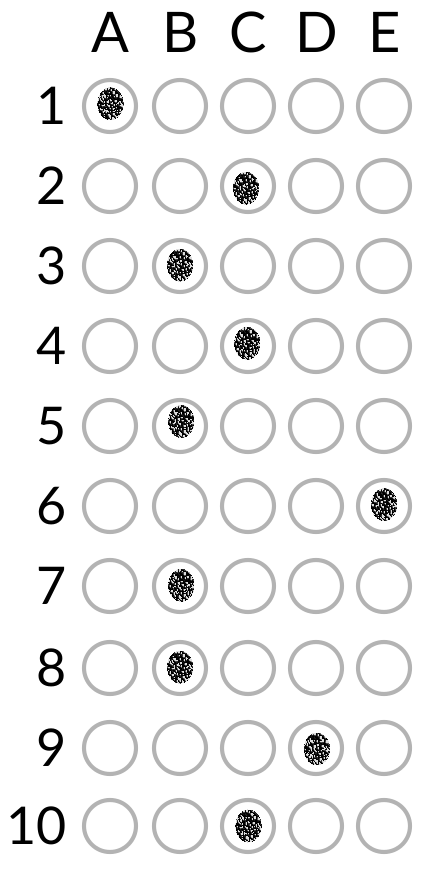

In [3]:
image = cv2.imread('answers_2.png')
cv2_imshow(image)

Konwersja do skali szarości

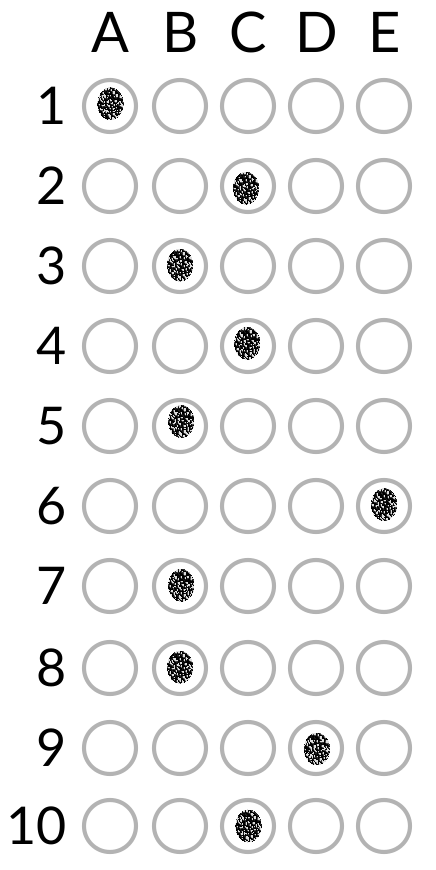

In [4]:
gray = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

Rozmycie

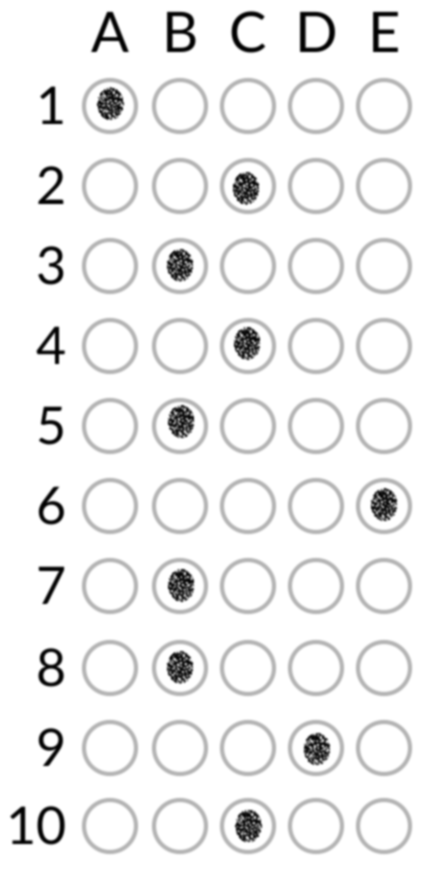

In [5]:
blurred = cv2.GaussianBlur(src=gray, ksize=(5, 5), sigmaX=0)
cv2_imshow(blurred)

Detekcja krawędzi

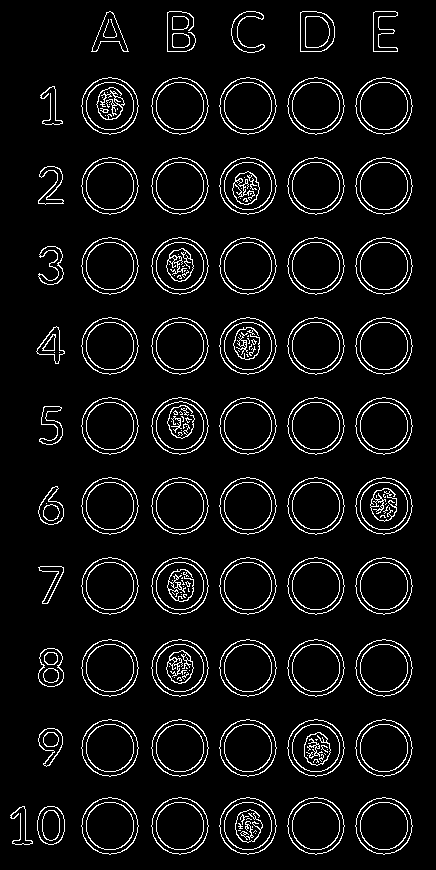

In [6]:
thresh = cv2.Canny(image=blurred, threshold1=70, threshold2=70)
cv2_imshow(thresh)

Ekstrakcja konturów

In [7]:
cnts = cv2.findContours(image=thresh.copy(), mode=cv2.RETR_EXTERNAL, method=cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
len(cnts)

68

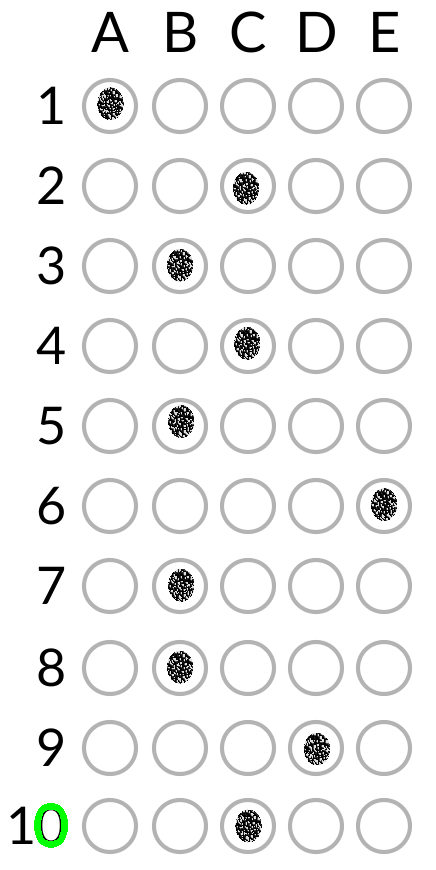

In [8]:
cnt1 = cv2.drawContours(image=image.copy(), contours=[cnts[0]], contourIdx=-1, color=(0, 255, 0), thickness=5)
cv2_imshow(cnt1)

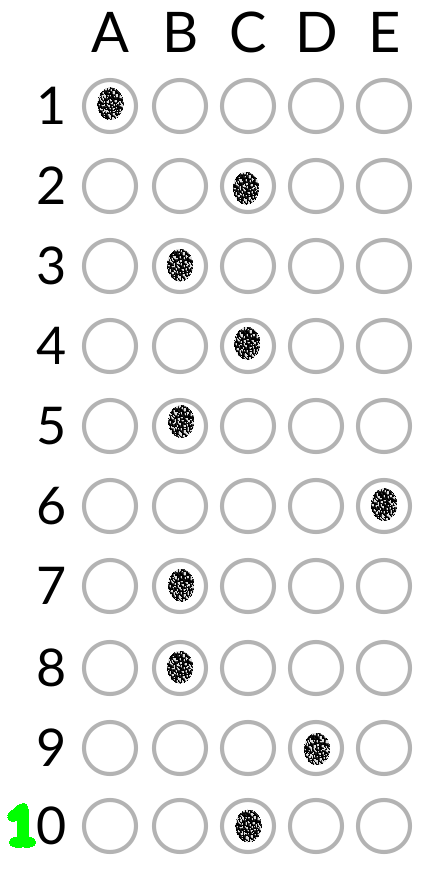

In [9]:
cnt1 = cv2.drawContours(image=image.copy(), contours=[cnts[1]], contourIdx=-1, color=(0, 255, 0), thickness=5)
cv2_imshow(cnt1)

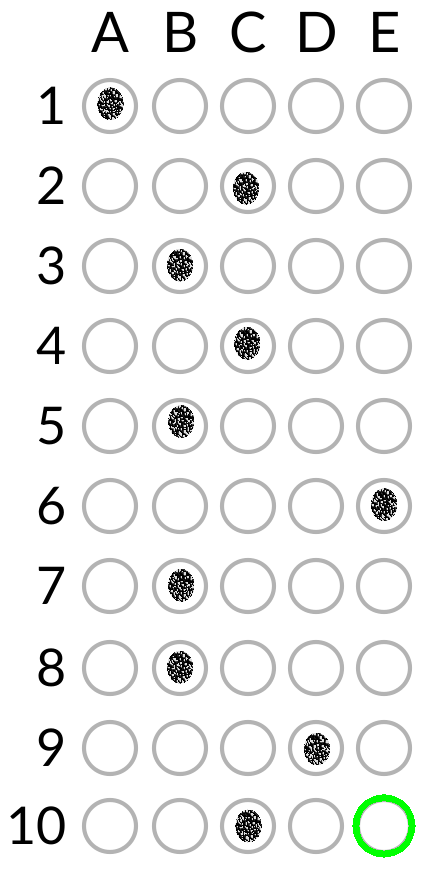

In [10]:
cnt1 = cv2.drawContours(image=image.copy(), contours=[cnts[2]], contourIdx=-1, color=(0, 255, 0), thickness=5)
cv2_imshow(cnt1)

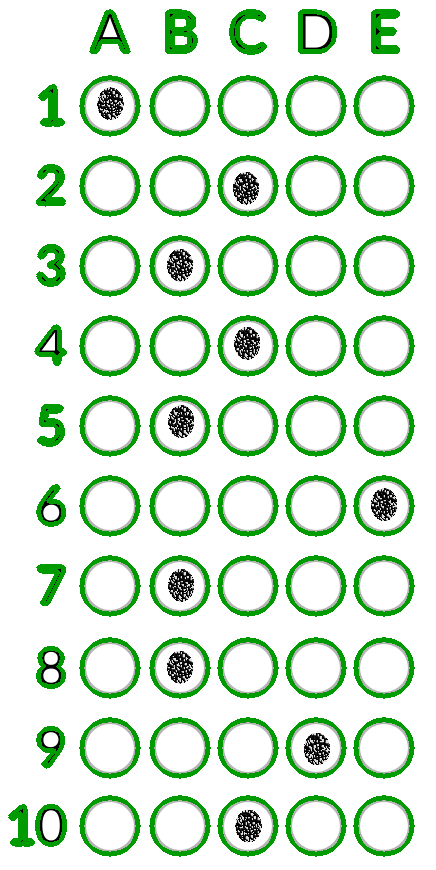

In [11]:
cnt_img = image.copy()
for contour in cnts:
  cv2.drawContours(cnt_img, [contour], contourIdx=-1, color=(0, 155, 0), thickness=3)
cv2_imshow(cnt_img)

Wydobycie odpowiednich konturów

Liczba pol z odpowiedziami: 1
Liczba pol z odpowiedziami: 2
Liczba pol z odpowiedziami: 3
Liczba pol z odpowiedziami: 4
Liczba pol z odpowiedziami: 5
Liczba pol z odpowiedziami: 6
Liczba pol z odpowiedziami: 7
Liczba pol z odpowiedziami: 8
Liczba pol z odpowiedziami: 9
Liczba pol z odpowiedziami: 10
Liczba pol z odpowiedziami: 11
Liczba pol z odpowiedziami: 12
Liczba pol z odpowiedziami: 13
Liczba pol z odpowiedziami: 14
Liczba pol z odpowiedziami: 15
Liczba pol z odpowiedziami: 16
Liczba pol z odpowiedziami: 17
Liczba pol z odpowiedziami: 18
Liczba pol z odpowiedziami: 19
Liczba pol z odpowiedziami: 20
Liczba pol z odpowiedziami: 21
Liczba pol z odpowiedziami: 22
Liczba pol z odpowiedziami: 23
Liczba pol z odpowiedziami: 24
Liczba pol z odpowiedziami: 25
Liczba pol z odpowiedziami: 26
Liczba pol z odpowiedziami: 27
Liczba pol z odpowiedziami: 28
Liczba pol z odpowiedziami: 29
Liczba pol z odpowiedziami: 30
Liczba pol z odpowiedziami: 31
Liczba pol z odpowiedziami: 32
Liczba pol z odpo

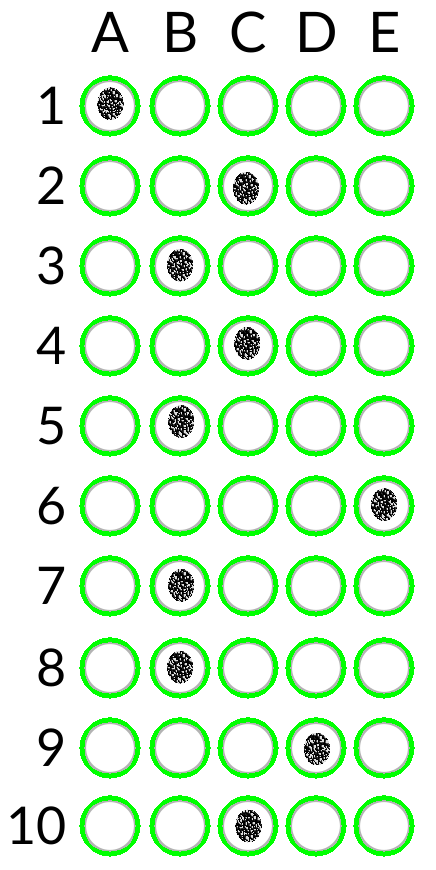

In [12]:
question_contours = []
for contour in cnts:
  (x, y, w, h) = cv2.boundingRect(contour)
  ar = w / float(h)

  if w >= 50 and h >= 50 and ar > 0.9 and 0.9 < ar< 1.1:
    question_contours.append(contour)
    print(f'Liczba pol z odpowiedziami: {len(question_contours)}')

cnt_img = image.copy()
for contour in question_contours:
  cv2.drawContours(cnt_img, [contour], contourIdx=-1, color=(0, 255, 0), thickness=3)
cv2_imshow(cnt_img)

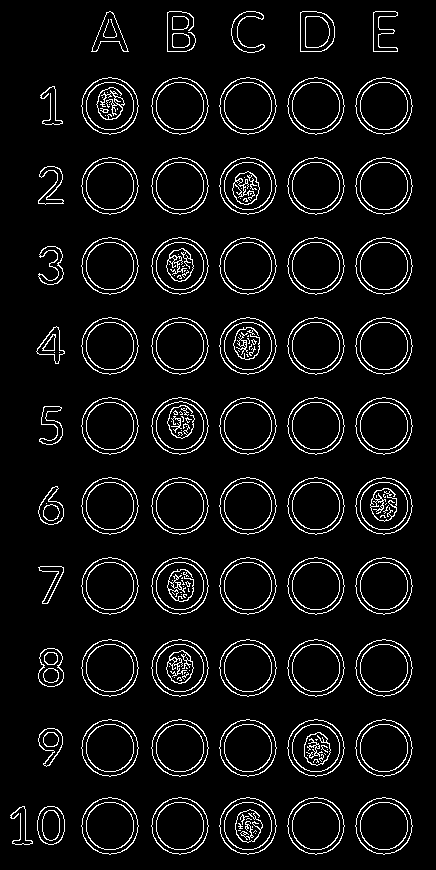

In [13]:
cv2_imshow(thresh)

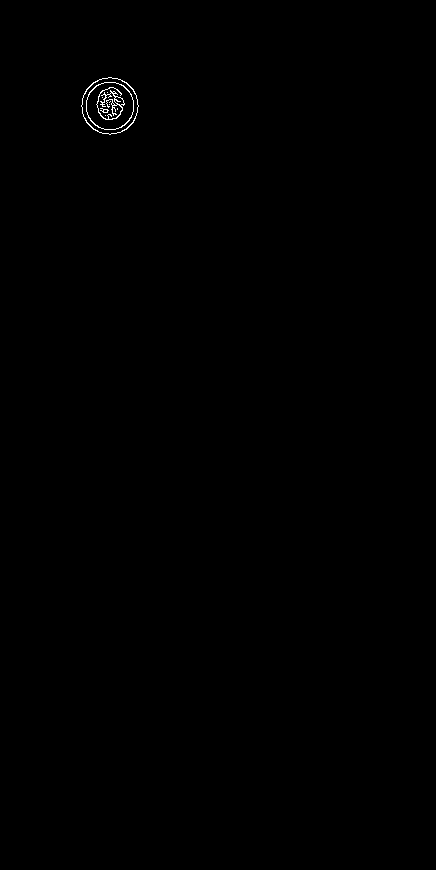

(664, 0)
1


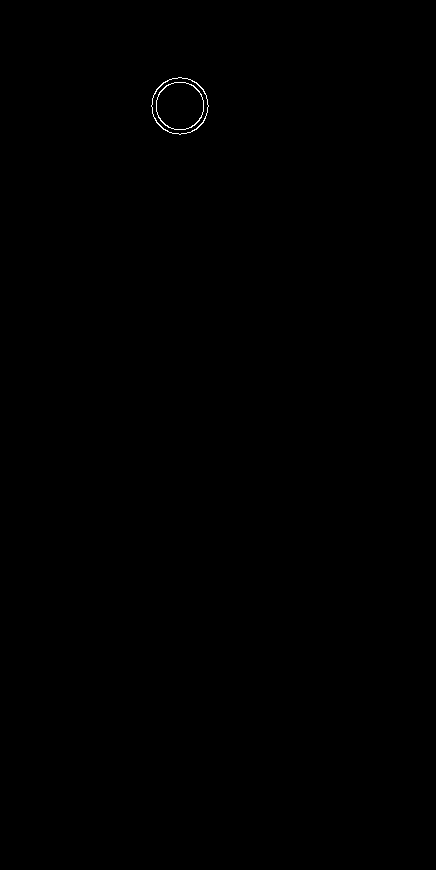

(664, 0)
1


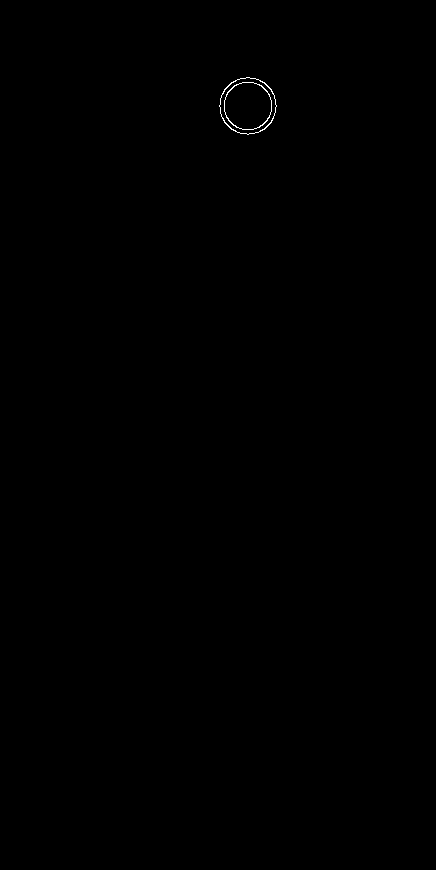

(664, 0)
1


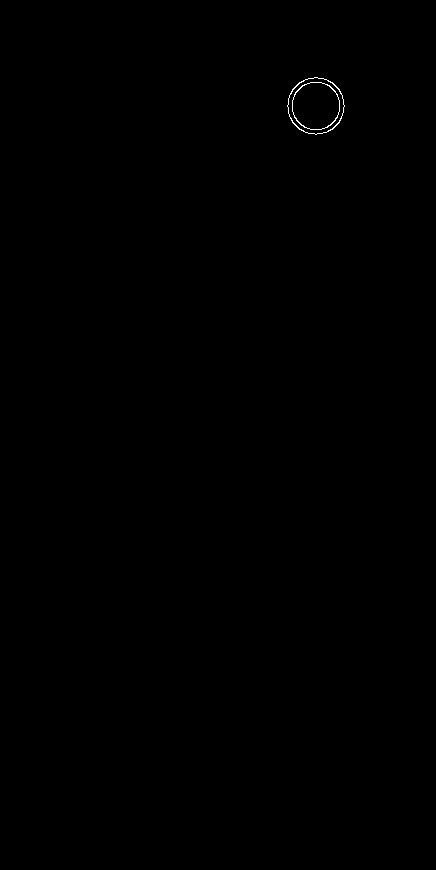

(664, 0)
1


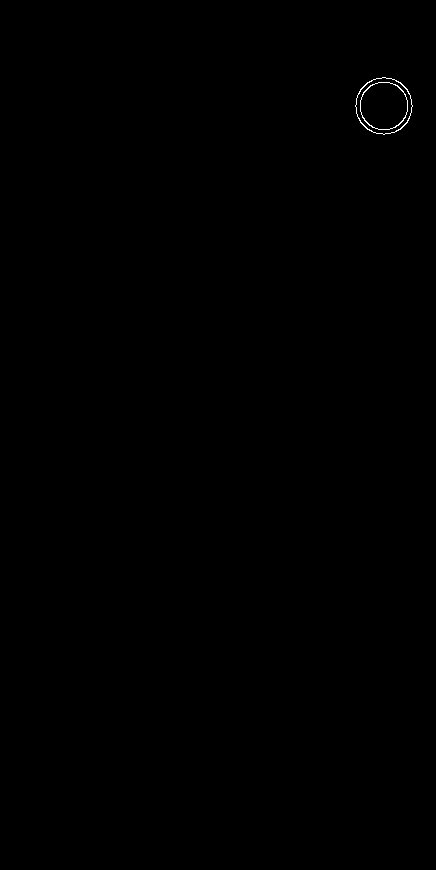

(664, 0)
1


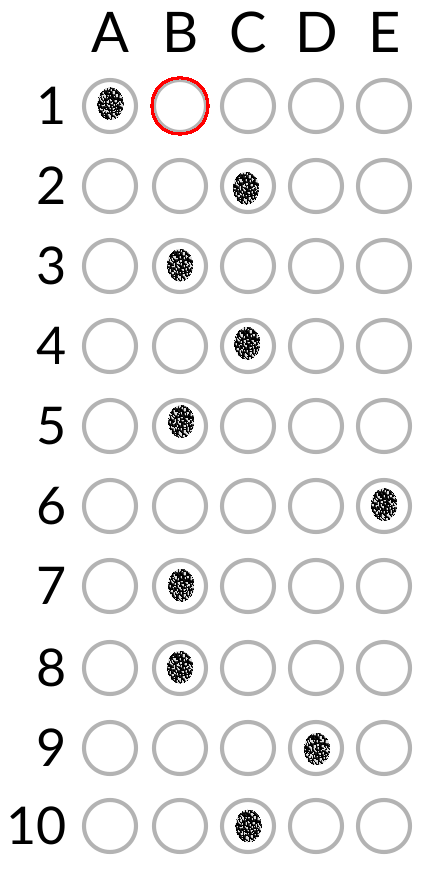

In [14]:
# sortowanie kontur od góry do dołu
question_top_bottom = imutils.contours.sort_contours(question_contours, method='top-to-bottom')[0]

# wydobycie pierwszych 5 konutr i sortowanie lewej do prawej
first_5 = question_top_bottom[:5]
first_5_left_right = imutils.contours.sort_contours(first_5, method='left-to-right')[0]

img = image.copy()

marked = None

for idx, contour in enumerate(first_5_left_right):
  #tworzymy maskę samych zer
  mask = np.zeros(thresh.shape, dtype='uint8')

  # rysujemy kontur na masce
  cv2. drawContours(mask, [contour], -1, 255, -1)

  # przeuprowadzamy operację bitwise_and na obrazie thresh.
  mask = cv2.bitwise_and(thresh, thresh, mask=mask)
  cv2_imshow(mask)

  # zliczamy liczbę pikseli niezerowych
  total = cv2.countNonZero(mask)

  if marked is None or total > marked[0]:
    marked = (total, idx)
  print(marked)

  # kolor czerwony
  color = (0, 0, 255)

  key = ANSWER_KEY[0]
  print(key)

  if key == marked[1]:
    #zaznacz kolor zielony
    color = (0, 255, 0)

cv2.drawContours(img, [first_5_left_right[key]], -1, color, 2)
cv2_imshow(img)

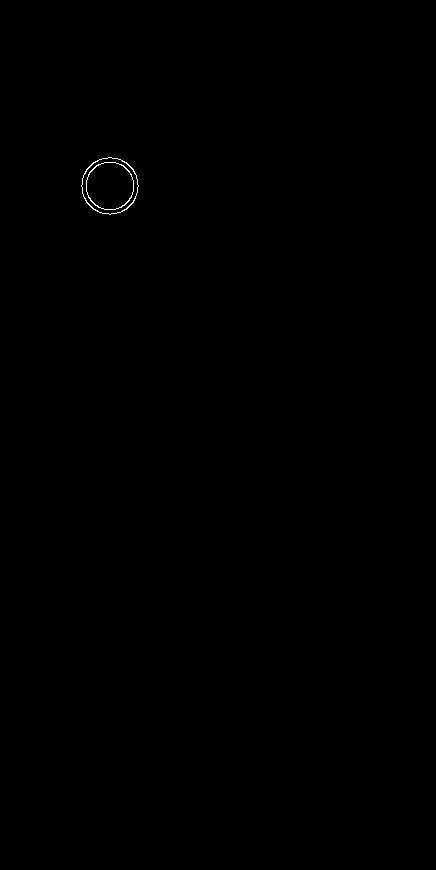

(375, 0)
3


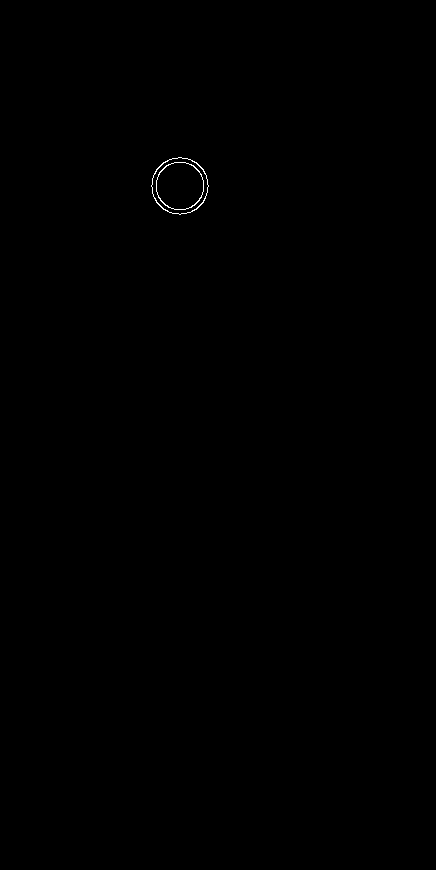

(375, 0)
3


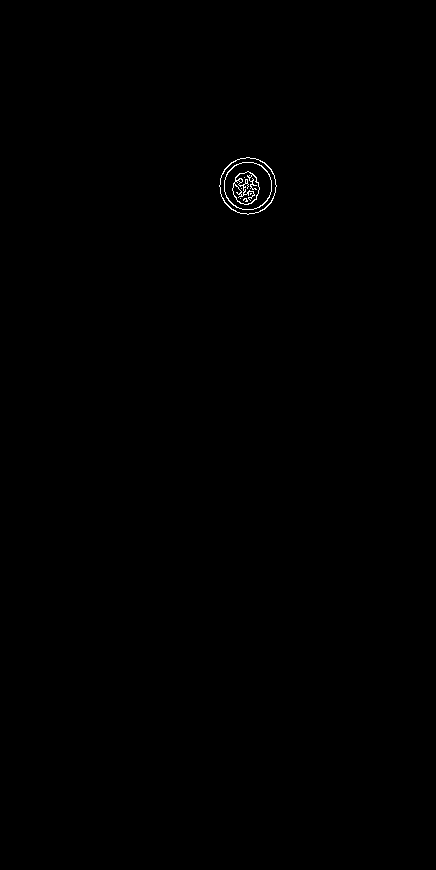

(661, 2)
3


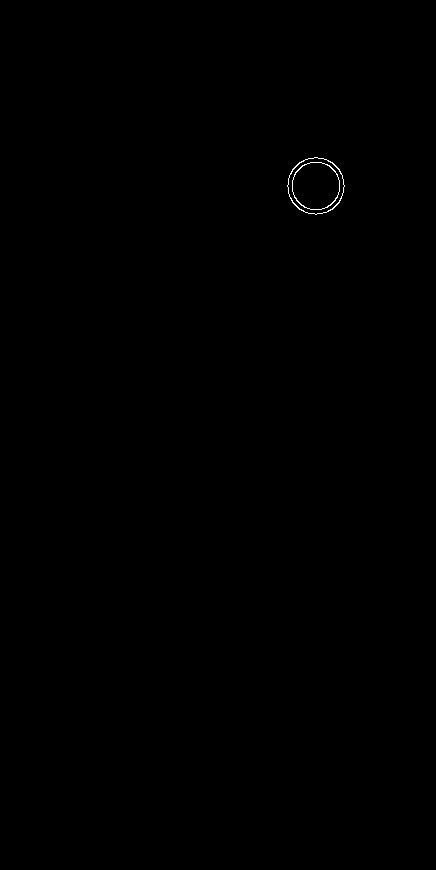

(661, 2)
3


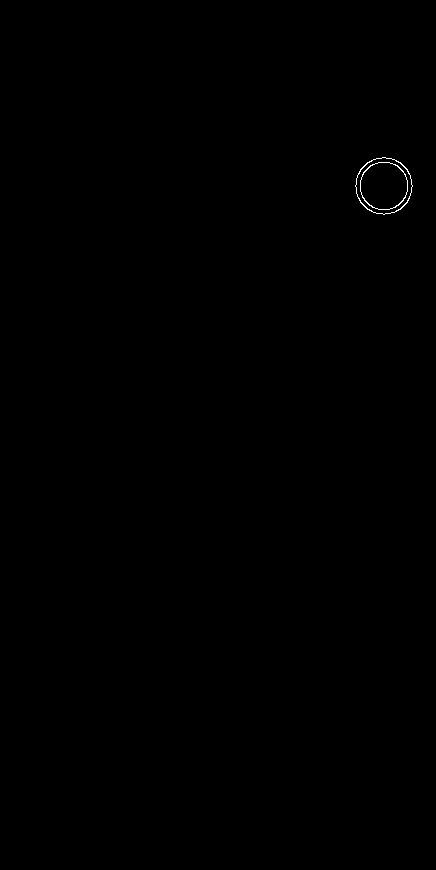

(661, 2)
3


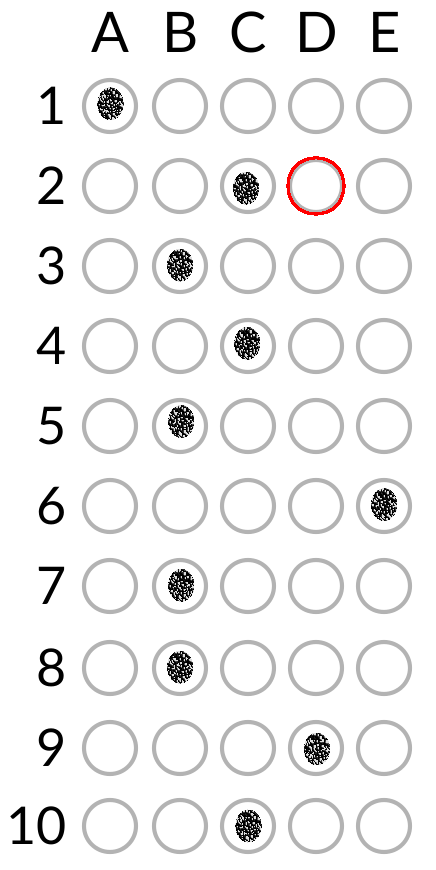

In [15]:
# sortowanie kontur od góry do dołu
question_top_bottom = imutils.contours.sort_contours(question_contours, method='top-to-bottom')[0]

# wydobycie pierwszych 5 konutr i sortowanie lewej do prawej
first_5 = question_top_bottom[5:10]
first_5_left_right = imutils.contours.sort_contours(first_5, method='left-to-right')[0]

img = image.copy()

marked = None

for idx, contour in enumerate(first_5_left_right):
  #tworzymy maskę samych zer
  mask = np.zeros(thresh.shape, dtype='uint8')

  # rysujemy kontur na masce
  cv2. drawContours(mask, [contour], -1, 255, -1)

  # przeuprowadzamy operację bitwise_and na obrazie thresh.
  mask = cv2.bitwise_and(thresh, thresh, mask=mask)
  cv2_imshow(mask)

  # zliczamy liczbę pikseli niezerowych
  total = cv2.countNonZero(mask)

  if marked is None or total > marked[0]:
    marked = (total, idx)
  print(marked)

  # kolor czerwony
  color = (0, 0, 255)

  key = ANSWER_KEY[1]
  print(key)

  if key == marked[1]:
    #zaznacz kolor zielony
    color = (0, 255, 0)

cv2.drawContours(img, [first_5_left_right[key]], -1, color, 2)
cv2_imshow(img)

Rozwiązanie dla wszystkich pytań

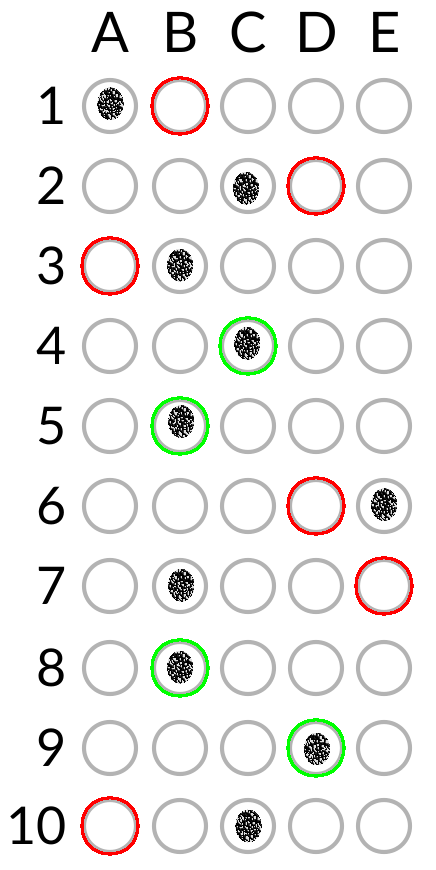

In [16]:
img = image.copy()

correct = 0

# sortowanie kontur od góry do dołu
question_top_bottom = imutils.contours.sort_contours(question_contours, method='top-to-bottom')[0]

for question, idx in enumerate(range(0, len(question_contours), 5)):

    # wydobycie pierwszych 5 kontur i sortowanie od lewej do prawej
    fields = question_top_bottom[idx:idx + 5]
    fields = imutils.contours.sort_contours(fields, method='left-to-right')[0]

    marked = None

    for cnt_idx, contour in enumerate(fields):
        # tworzymy maskę z samych zer
        mask = np.zeros(thresh.shape, dtype='uint8')

        # rysujemy kontur na masce
        cv2.drawContours(mask, [contour], -1, 255, -1)

        # przeprowadzamy operację bitwise_and na obrazie thresh
        mask = cv2.bitwise_and(thresh, thresh, mask=mask)

        # zliczamy liczbę pikseli niezerowych
        total = cv2.countNonZero(mask)


        if marked is None or total > marked[0]:
            marked = (total, cnt_idx)

    # kolor czerwony
    color = (0, 0, 255)

    key = ANSWER_KEY[question]

    if key == marked[1]:
        # zaznacz na kolor zielony
        color = (0, 255, 0)
        correct += 1

    cv2.drawContours(img, [fields[key]], -1, color, 2)

cv2_imshow(img)

Wyświetlanie rozwiązania

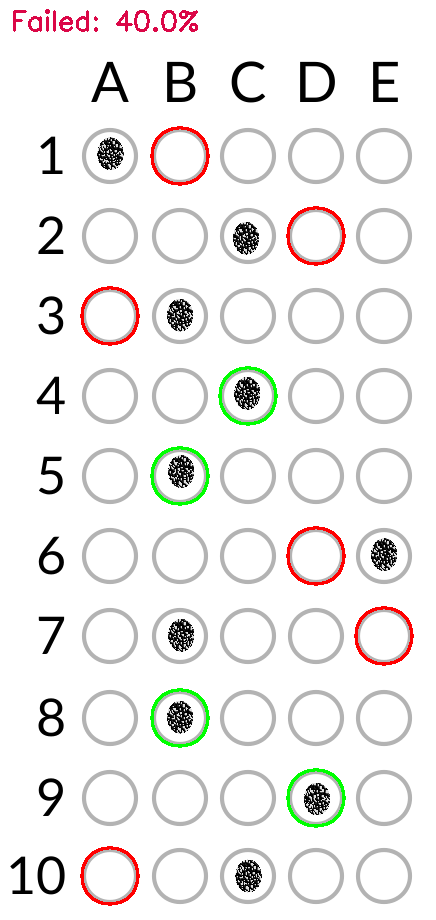

In [17]:
# dodanie górnego obramowania
checked = cv2.copyMakeBorder(
    src=img,
    top=50,
    bottom=0,
    left=0,
    right=0,
    borderType=cv2.BORDER_CONSTANT,
    value=(255, 255, 255)
)

score = (correct / 10)

color = (50, 168, 82) if score >= 0.6 else (71, 7, 219)
text = 'Passed' if score >= 0.6 else 'Failed'

cv2.putText(img=checked, text=f'{text}: {score * 100}%', org=(10, 30), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.9, color=color, thickness=2)
cv2_imshow(checked)

In [18]:
cv2.imwrite(filename='checked.png', img=checked)

True